## Decision Tree & Random Forest Models Training & Evaluation

### This section trains and evaluates two tree-based models:
- Decision Tree
- Random Forest

The goal is to predict whether a crash would result in an injury or not

The model performance is also going to be compared across 3 feature sets:
- Core features: the baseline -> a subset of key variables deemed to be the most important
- Forward-Selected Features: using the forward stepwise selection process at a feature group level (variables are going to be grouped first)
- All Features: the full set of variables

The models performance will be evaluated using:
- ROC-AUC
- ROC Curves
- Confusion matrix

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error

### Step 1: Load processed data sets (train, validation and test sets)

In [32]:
data_dir = "../Data/Processed"

#Load processed input data
input_x_training_data = np.load(f"{data_dir}/X_train_processed.npy")
input_x_validation_data = np.load(f"{data_dir}/X_val_processed.npy")
input_x_test_data = np.load(f"{data_dir}/X_test_processed.npy")

In [33]:
print(input_x_training_data.shape)
print(input_x_validation_data.shape)
print(input_x_test_data.shape)

(5334, 89)
(1779, 89)
(1779, 89)


In [35]:
#load processed target data
input_y_training_data = pd.read_csv(f"{data_dir}/y_train.csv")
input_y_validation_data = pd.read_csv(f"{data_dir}/y_val.csv")
input_y_test_data = pd.read_csv(f"{data_dir}/y_test.csv")

In [36]:
print(input_y_training_data.shape)
print(input_y_validation_data.shape)
print(input_y_test_data.shape)

(5334, 1)
(1779, 1)
(1779, 1)


### Step 2: Define Feature Sets

In [37]:
#load in feature names
features_df = pd.read_csv(r"C:\Users\micha\Documents\SYSTEMS DESIGN ENGINEERING\SYDE 4B WINTER TERM 2026\MSE 446 - Introduction to Machine Learning\traffic-collision-model\Data\Processed\feature_names.csv")
features_df

,feature_name
0,num__ACCIDENT_HOUR
1,num__THRULANENO
2,num__NORTHBOUNDDISOBEYCOUNT
3,num__SOUTHBOUNDDISOBEYCOUNT
4,cat__ACCIDENT_WEEKDAY_Friday
...,...
84,cat__CYCLISTINVOLVED_yes
85,cat__MOTORCYCLISTINVOLVED_no
86,cat__MOTORCYCLISTINVOLVED_yes
87,cat__VULNERABLE_USER_INVOLVED_no


In [38]:
#create a list containing all the feature names
feature_names = features_df["feature_name"].tolist()
feature_names

['num__ACCIDENT_HOUR',
 'num__THRULANENO',
 'num__NORTHBOUNDDISOBEYCOUNT',
 'num__SOUTHBOUNDDISOBEYCOUNT',
 'cat__ACCIDENT_WEEKDAY_Friday',
 'cat__ACCIDENT_WEEKDAY_Monday',
 'cat__ACCIDENT_WEEKDAY_Saturday',
 'cat__ACCIDENT_WEEKDAY_Sunday',
 'cat__ACCIDENT_WEEKDAY_Thursday',
 'cat__ACCIDENT_WEEKDAY_Tuesday',
 'cat__ACCIDENT_WEEKDAY_Wednesday',
 'cat__ACCIDENTLOCATION_At intersection',
 'cat__ACCIDENTLOCATION_At railway crossing',
 'cat__ACCIDENTLOCATION_At/near private drive',
 'cat__ACCIDENTLOCATION_Intersection related',
 'cat__ACCIDENTLOCATION_Non intersection',
 'cat__ACCIDENTLOCATION_Other',
 'cat__ACCIDENTLOCATION_Overpass or bridge',
 'cat__ACCIDENTLOCATION_Underpass or tunnel',
 'cat__INITIALIMPACTTYPE_Angle',
 'cat__INITIALIMPACTTYPE_Approaching',
 'cat__INITIALIMPACTTYPE_Other',
 'cat__INITIALIMPACTTYPE_Rear end',
 'cat__INITIALIMPACTTYPE_SMV other',
 'cat__INITIALIMPACTTYPE_SMV unattended vehicle',
 'cat__INITIALIMPACTTYPE_Sideswipe',
 'cat__INITIALIMPACTTYPE_Turning movemen

In [39]:
#select the feature indices based on the names of the features
def select_features(names):
    i = 0
    result = []
    #loop through each feature name
    for name in feature_names:
        #check the current feature matches the feature used for the feature selection
        if any(j in name for j in names):
            result.append(i)
        i += 1
    return result

#### 1. Core Features: Acts as the baseline
Includes:
- Environmental conditions
- Time
- Location
- Traffic control
- Collision type
- Vulnerable road user involvement

This set can be changed and was based on our interpretation of what the "core" variables were

In [40]:
#Selecting core feature set
core_features = select_features([
    "ENVIRONMENTCONDITION1",
    "LIGHT",
    "ACCIDENT_HOUR",
    "ACCIDENT_WEEKDAY",
    "ACCIDENTLOCATION",
    "COLLISIONTYPE",
    "TRAFFICCONTROL",
    "PEDESTRIANINVOLVED",
    "CYCLISTINVOLVED",
    "MOTORCYCLISTINVOLVED"
])

#### 2. Forward-Selected Features
We'll group features into feature groups e.g. Environment will contain 'ENVIRONMENTCONDITION1, LIGHT' etc. Group will only be added one at a time and will only be kept if they improve the ROC-AUC

In [41]:
#grouping each of the features that are "linked"
feature_groups = {
    "environment": ["ENVIRONMENTCONDITION1", "LIGHT"],
    "time": ["ACCIDENT_HOUR", "ACCIDENT_WEEKDAY"],
    "location": ["ACCIDENTLOCATION"],
    "collision": ["COLLISIONTYPE"],
    "traffic": ["TRAFFICCONTROL", "TRAFFICCONTROLCONDITION"],
    "vulnerable": ["PEDESTRIANINVOLVED", "CYCLISTINVOLVED", "MOTORCYCLISTINVOLVED"]
}

#mapping each of the columns (feature indices) to their feature groups
group_columns = {
    feature_group: select_features(features)
    for feature_group, features in feature_groups.items()
}

group_columns

{'environment': [40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80],
 'time': [0, 4, 5, 6, 7, 8, 9, 10],
 'location': [11, 12, 13, 14, 15, 16, 17, 18],
 'collision': [],
 'traffic': [56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72],
 'vulnerable': [81, 82, 83, 84, 85, 86]}

In [42]:
from sklearn.metrics import (
    roc_auc_score,
    classification_report
)

In [43]:
#forward stepwise selection process

selected_groups = []
forward_selected_features = []

best_auc = 0

for group_name, cols in group_columns.items():
    #create a temporary list to contain features we have with features being added
    temp_features = forward_selected_features + cols
    #adding training data
    x_train = input_x_training_data[:, temp_features]
    #adding validation data
    x_validate = input_x_validation_data[:, temp_features]

    model = RandomForestClassifier(
        n_estimators = 100,
        max_depth = 10,
        class_weight = "balanced",
        random_state = 42,
        n_jobs =- 1
    )
    model.fit(x_train, input_y_training_data)
    val_auc = roc_auc_score(input_y_validation_data, model.predict_proba(x_validate)[:, 1])

    #condition to add features or not
    if val_auc > best_auc:
        #update the best_auc score
        best_auc = val_auc
        #add features if the auc score is improved
        selected_groups.append(group_name)
        #updated the forward selected features to include existing set of features
        forward_selected_features = temp_features

print(f"Validation AUC: {round(best_auc, 3)}")
print(f"Selected groups: {selected_groups}")

C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa

Validation AUC: 0.765
Selected groups: ['environment', 'time', 'location', 'traffic', 'vulnerable']


#### 3. All Features
Includes all the features would be the most complex model

In [44]:
all_features = list(range(len(feature_names)))
all_features

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88]

In [45]:
#use dictionary to store all the feature sets
feature_sets = {
    "Core Features": core_features,
    "Forward Selected Features": forward_selected_features,
    "All Features": all_features
}
feature_sets

{'Core Features': [0,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86],
 'Forward Selected Features': [40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  0,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  81,
  82,
  83,
  84,
  85,
  86],
 'All Features': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,


#### Decision Tree
For each set of features:
- trial and error will be used for max_depth when testing on the validation set (hyperparameter tuning)
- ROC-AUC will be used for performance -> depth with highest ROC-AUC is chosen
- the final model will be trained using that depth

In [ ]:
decision_tree_results = {}

tree_depth_test = [3, 4, 5, 6, 7, 8]
for feature_set_name, cols in feature_sets.items():

    best_depth = None
    best_auc = 0
    
    #only include the columns for this feature set
    X_tr = input_x_training_data[:, cols]
    X_val = input_x_validation_data[:, cols]
    X_te = input_x_test_data[:, cols]
    
    #test each candidate depth
    for depth in tree_depth_test:
        model = DecisionTreeClassifier(
            max_depth = depth,
            class_weight = "balanced",
            random_state = 42
        )
        model.fit(X_tr, input_y_training_data)

        val_auc = roc_auc_score(input_y_validation_data, model.predict_proba(X_val)[:, 1])

        #update the best depth if the AUC improves
        if val_auc > best_auc:
            best_auc = val_auc
            best_depth = depth

    #train the model using the best depth
    best_model = DecisionTreeClassifier(
        max_depth = best_depth,
        class_weight = "balanced",
        random_state = 42
    )
    best_model.fit(X_tr, input_y_training_data)

    #the predicted probabilities would be
    y_probability = best_model.predict_proba(X_te)[:, 1]

    #convert probabilites to class labels
    y_prediction = best_model.predict(X_te)

    testing_auc = roc_auc_score(input_y_test_data, y_probability)
    test_rmse = np.sqrt(mean_squared_error(input_y_test_data, y_prediction))
    
    #check for overfitting
    #checking to see how the model performs when using the training set compared to the test set
    train_probability = best_model.predict_proba(X_tr)[:, 1]
    train_auc = roc_auc_score(input_y_training_data, train_probability)
    
    #Results for every feature set
    print(feature_set_name)
    print(f"Best Max Depth: {best_depth}")
    print(classification_report(input_y_test_data, y_prediction, target_names=['No Injury', 'Injury']))
    print(f"Train AUC: {train_auc}")
    print(f"Test AUC: {testing_auc}")
    print(f"Test RMSEL {test_rmse}")

    #use dictionary to store results
    decision_tree_results[feature_set_name] = {
        "model": best_model,
        "features": cols,
        "test_prediction": y_prediction,
        "test_probability": y_probability,
        "test_auc": testing_auc,
        "train_auc": train_auc
    }

Core Features
Best Max Depth: 4
              precision    recall  f1-score   support

   No Injury       0.92      0.84      0.88      1537
      Injury       0.33      0.51      0.40       242

    accuracy                           0.79      1779
   macro avg       0.63      0.68      0.64      1779
weighted avg       0.84      0.79      0.81      1779

Train AUC: 0.7213407084309535
Test AUC: 0.7169636567962706
Forward Selected Features
Best Max Depth: 4
              precision    recall  f1-score   support

   No Injury       0.92      0.84      0.88      1537
      Injury       0.33      0.51      0.40       242

    accuracy                           0.79      1779
   macro avg       0.63      0.68      0.64      1779
weighted avg       0.84      0.79      0.81      1779

Train AUC: 0.7213407084309535
Test AUC: 0.7169636567962706
All Features
Best Max Depth: 6
              precision    recall  f1-score   support

   No Injury       0.92      0.82      0.87      1537
      Injury

#### Decision Tree Analysis

Recall is the proportion of correctly classified positive cases, in this context, recall is:



$$\frac{\text{No. of correctly identified injured cases}}{\text{No. of correctly identified injured cases} + \text{No. of incorrectly identified non-injured cases}}$$

Recall is important when working with collision data as we want to identify as ma


* Best Performance: **All features** model (Test AUC of 0.7787)
* Best Max Depth: 6
* Highest Injury Recall: **All features** model (Recall = 0.55)

#### Random Forest
Same features used, same tuning process used

In [ ]:
random_forest_results = {}

#random forests are less suseptible to overfitting, so higher depths used
tree_depth_test = [5, 6, 7, 8, 10, 15]
for feature_set_name, cols in feature_sets.items():

    best_depth = None
    best_auc = 0
    
    #only include the columns for this feature set
    X_tr = input_x_training_data[:, cols]
    X_val = input_x_validation_data[:, cols]
    X_te = input_x_test_data[:, cols]
    
    #test each candidate depth
    for depth in tree_depth_test:
        model = RandomForestClassifier(
            max_depth = depth,
            class_weight = "balanced",
            random_state = 42,
            n_jobs =- 1
        )
        model.fit(X_tr, input_y_training_data)

        val_auc = roc_auc_score(input_y_validation_data, model.predict_proba(X_val)[:, 1])

        #update the best depth if the AUC improves
        if val_auc > best_auc:
            best_auc = val_auc
            best_depth = depth

    #train the model using the best depth
    best_model = RandomForestClassifier(
        max_depth = best_depth,
        class_weight = "balanced",
        random_state = 42,
        n_jobs =- 1
    )
    best_model.fit(X_tr, input_y_training_data)

    #the predicted probabilities would be
    y_probability = best_model.predict_proba(X_te)[:, 1]

    #convert probabilites to class labels
    y_prediction = best_model.predict(X_te)

    testing_auc = roc_auc_score(input_y_test_data, y_probability)

    #check for overfitting
    #checking to see how the model performs when using the training set compared to the test set
    train_probability = best_model.predict_proba(X_tr)[:, 1]
    train_auc = roc_auc_score(input_y_training_data, train_probability)

    # RMSE

    test_rmse = np.sqrt(mean_squared_error(input_y_test_data, y_prediction))

    #Results for every feature set
    print(feature_set_name)
    print(f"Best Max Depth: {best_depth}")
    print(classification_report(input_y_test_data, y_prediction, target_names=['No Injury', 'Injury']))
    print(f"Train AUC: {train_auc}")
    print(f"Test AUC: {testing_auc}")
    print(f"Test RMSE: {test_rmse}")

    #use dictionary to store results
    random_forest_results[feature_set_name] = {
        "model": best_model,
        "features": cols,
        "test_prediction": y_prediction,
        "test_probability": y_probability,
        "test_auc": testing_auc
    }

C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa

Core Features
Best Max Depth: 6
              precision    recall  f1-score   support

   No Injury       0.92      0.81      0.86      1537
      Injury       0.32      0.57      0.41       242

    accuracy                           0.78      1779
   macro avg       0.62      0.69      0.64      1779
weighted avg       0.84      0.78      0.80      1779

Train AUC: 0.7766197542224633
Test AUC: 0.7535837764884905


C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa

Forward Selected Features
Best Max Depth: 7
              precision    recall  f1-score   support

   No Injury       0.92      0.82      0.87      1537
      Injury       0.33      0.58      0.42       242

    accuracy                           0.78      1779
   macro avg       0.63      0.70      0.64      1779
weighted avg       0.84      0.78      0.81      1779

Train AUC: 0.7861193823524932
Test AUC: 0.754762685708448


C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\micha\anaconda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa

All Features
Best Max Depth: 8
              precision    recall  f1-score   support

   No Injury       0.92      0.86      0.89      1537
      Injury       0.39      0.55      0.45       242

    accuracy                           0.82      1779
   macro avg       0.66      0.71      0.67      1779
weighted avg       0.85      0.82      0.83      1779

Train AUC: 0.8699988266166342
Test AUC: 0.8223422788839481


#### Random Forest analysis

* Best Model: **All features** model (Test AUC = 0.822)
* Best Max Depth: 8
* Highest Injury Recall: **All features** model (Recall = 0.55)

#### Feature Importance

In [49]:
#find the best performing random forest
best_random_forest_name = None
best_random_forest_auc = 0

for name, result in random_forest_results.items():
    if result["test_auc"] > best_random_forest_auc:
        best_random_forest_auc = result["test_auc"]
        best_random_forest_name = name

best_random_forest = random_forest_results[best_random_forest_name]

#find the model and the column indices used to train it
best_random_forest_model = best_random_forest["model"]
cols = best_random_forest["features"]

#map indices back to the features
labels = []
for i in cols:
    #remove preceding num, cat that was added during preprocessing
    label = feature_names[i].replace("num__", "").replace("cat__", "")
    labels.append(label)
print(best_random_forest_name)

All Features


In [50]:
#get the gini scores for every feature
gini_score = pd.Series(
    best_random_forest_model.feature_importances_,
    index = labels
)
gini_score.sort_values(ascending=False).head(10)

VULNERABLE_USER_INVOLVED_yes                0.129415
VULNERABLE_USER_INVOLVED_no                 0.126768
INITIALIMPACTTYPE_SMV unattended vehicle    0.109683
PEDESTRIANINVOLVED_yes                      0.062961
PEDESTRIANINVOLVED_no                       0.050314
ACCIDENT_HOUR                               0.040901
IMPACTLOCATION_Within intersection          0.040607
ACCIDENTLOCATION_At intersection            0.034573
INITIALIMPACTTYPE_SMV other                 0.028028
CYCLISTINVOLVED_yes                         0.024703
dtype: float64

### ROC Curves

In [51]:
from sklearn.metrics import roc_curve

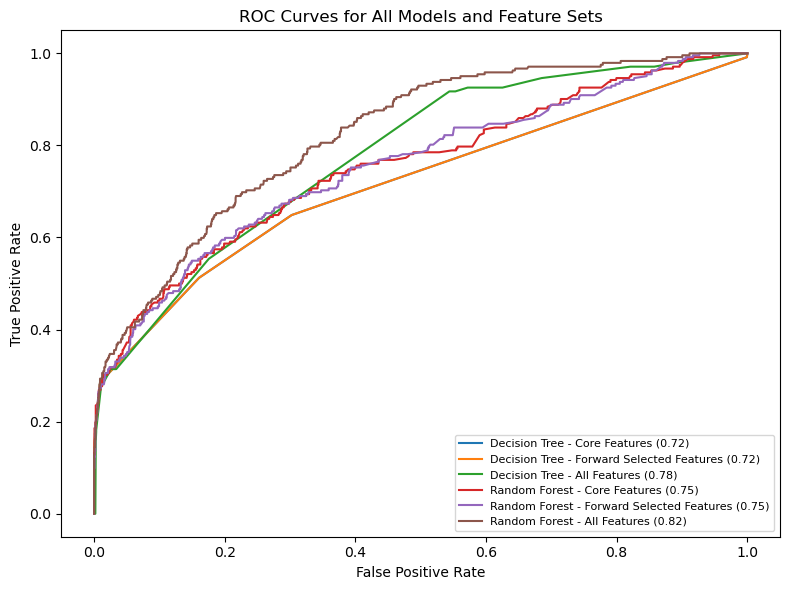

In [52]:
plt.figure(figsize=(8, 6))

#plot ROC curve for decision tree
for name, result in decision_tree_results.items():
    fpr, tpr, _ = roc_curve(input_y_test_data, result["test_probability"])
    plt.plot(fpr, tpr, label=f"Decision Tree - {name} ({result["test_auc"]:.2f})")

#plot ROC curve for random forest
for name, result in random_forest_results.items():
    fpr, tpr, _ = roc_curve(input_y_test_data, result["test_probability"])
    plt.plot(fpr, tpr, label=f"Random Forest - {name} ({result["test_auc"]:.2f})")

    
#creating the chart
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models and Feature Sets")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

The Random Forest appears to consistently outperform the Decision Tree across all the feature sets. The brown curve (Random Forest All Features) separates from the rest of the curves especially between the 0.2 and 0.6 false positive rate, where it maintains a higher true positive rate.
Important to notice is that the Core and Forward Selected features are nearly identical for both Decision Tree and Random Forest models, however the gap between the Core/Forward Selected features and the All features set is greater in the Random Forest model compared to the Decision Tree model.

#### Confusion Matrix

In [53]:
from sklearn.metrics import(
    confusion_matrix,
    ConfusionMatrixDisplay
)

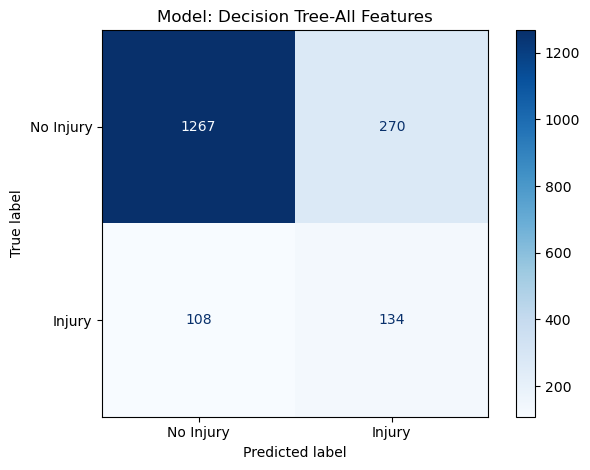

In [54]:
#plot Confusion Matrix for decision tree
auc = 0
best_name = ""
predictor = None


for name, result in decision_tree_results.items():
    if result["test_auc"] > auc:
        auc = result["test_auc"]
        predictor = result["test_prediction"]
        best_name = name
        

cm = confusion_matrix(input_y_test_data, predictor)
ConfusionMatrixDisplay(cm, display_labels=["No Injury", "Injury"]).plot(cmap="Blues")
plt.title(f"Model: Decision Tree-{best_name}")
plt.tight_layout()
plt.show()

##### Decision Tree Confusion Matrix Analaysis

It is evident that there is a large amount of True Positives (1267) detected in the Decision Tree model (compared to the other values in the matrix) which is crucial.  

The second largest value is the quantity of False Positives (270), this trade-off is acceptable as we should be willing to sacrifice incorrectly classified non-injury cases, if it means we can have more correcly classified injury cases.

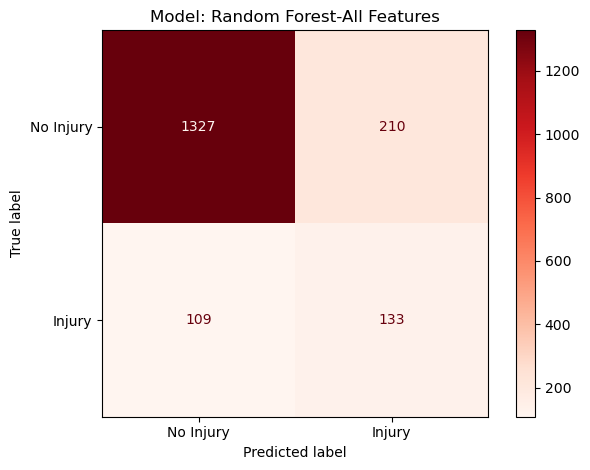

In [55]:
#plot Confusion Matrix for random forest tree
auc = 0
best_name = ""
predictor = None


for name, result in random_forest_results.items():
    if result["test_auc"] > auc:
        auc = result["test_auc"]
        predictor = result["test_prediction"]
        best_name = name
        

cm = confusion_matrix(input_y_test_data, predictor)
ConfusionMatrixDisplay(cm, display_labels=["No Injury", "Injury"]).plot(cmap="Reds")
plt.title(f"Model: Random Forest-{best_name}")
plt.tight_layout()
plt.show()

##### Random Forest Confusion Matrix Analaysis

It is evident that there is a large amount of True Positives (1327) detected in the Decision Tree model (compared to the other values in the matrix) which is crucial.  

The second largest value is the quantity of False Positives (210), this trade-off is acceptable as we should be willing to sacrifice incorrectly classified non-injury cases, if it means we can have more correcly classified injury cases.

### Final Summary

In this project, both the Decision Tree and Random Forest models were developed to predict if a road accident led to an injury or not. Both models were trained using processed collision data and evaluated using a train-validation-test workflow on three feature sets: A set of Core features, Forward Selected Features and All the features.

The baseline Decision Tree model performed decently with the Core and Forward Selected feature sets both achieving a ROC-AUC of 0.72. Deeper trees were found to have some instances of overfitting as the training AUC was higher than the testing AUC for when testing each of the three feature sets

The Random Forest consistently outperformed the Decusion Tree across all feature sets. The Core and Forward Selected feature sets had ROC-AUC of 0.75 while the All features set had one of 0.82. The ensemble approach helped reduce overfitting as it was lower for all feature sets, by averaging predictions across many trees, each being trained on a random subset of features.

It was interesting to find that the performance between the feature sets were relatively close. The Core and Forward Selected feature sets were almost identical, which suggests that the core variables captured most the of useful 'data'. Understandably, the best performance came from including all features, especially including the vulnerable road user involvement, which came to show that it was a very strong predictor of injury severity through feature importance analysis

Overall, the Random Forest with All Features is the strongest model, achieving a ROC-AUC of 0.82 on the test set. Despite some limitations by using the default threshold of 0.5, the model was able to identify a meaningful proportion of injury cases which could be used to provide insight into the factors that contribute to injuries in the event of an accident.